In [2]:
%autoreload 2

In [1]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

pink = "#FB008C"
green = "#72D100"
cmap_conv = LinearSegmentedColormap.from_list("conv",[green, (1, 1, 1), pink])
cmap_conj = cm.get_cmap('coolwarm_r')

plt.rcParams.update({'font.size': 13})

C:\Users\Zichen\AppData\Local\Temp\ipykernel_25980\1284024126.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_conj = cm.get_cmap('coolwarm_r')


__BOUT FINDER__

In [3]:
path = "C://Data//Imaging//"
genotypes = {
    'Casper':
        [r"C:\Data\Imaging\260325_frmd7\fish9",
        r"C:\Data\Imaging\260325_frmd7\fish11",
        r"C:\Data\Imaging\260325_frmd7\fish12",
        r"C:\Data\Imaging\260325_frmd7\fish13",
        r"C:\Data\Imaging\260325_frmd7\fish16"],
    'frmd7KO':
        [r"C:\Data\Imaging\260325_frmd7\fish17",
        r"C:\Data\Imaging\260325_frmd7\fish7",
        r"C:\Data\Imaging\260325_frmd7\fish8",
        r"C:\Data\Imaging\260325_frmd7\fish10",
        r"C:\Data\Imaging\260325_frmd7\fish14"]}
all_dfs = []
for geno in genotypes.keys():
    for fish in genotypes[geno]:
        saccade_df = pd.read_csv( fish + '//eye//eye_saccade_df.csv', index_col=0)
        saccade_df.loc[:, "fish_id"] = fish
        saccade_df.loc[:, "Genotype"] = geno
        all_dfs.append(saccade_df)
all_dfs = pd.concat(all_dfs).reset_index(drop = True)

In [7]:
all_dfs = all_dfs.drop(['cont_tuples_realtime_s', 'cont_tuples_eyeindex', 'eye_stimuli'], axis = 1).groupby(['eye_realstimuli', 'fish_id', 'Genotype']).mean().reset_index()

In [14]:
stimorder = ['stationary', 'left', 'right']

In [20]:
utils.stim_colors['stationary']

(0.8, 0.8, 0.8, 1)

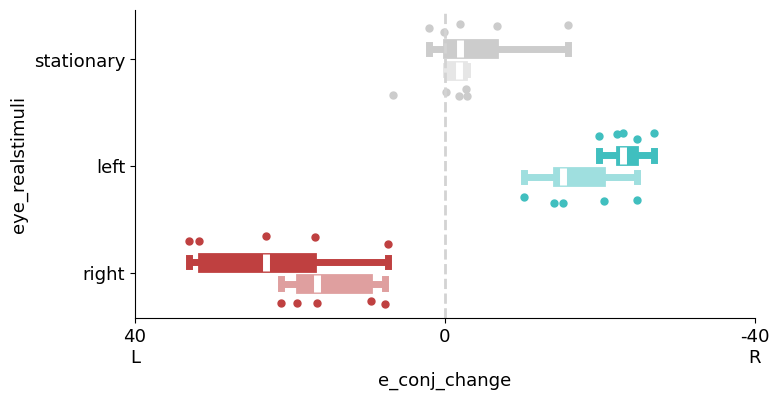

In [87]:
def plot_fish_saccade(all_df, stimorder, params, genotype):
    """Plot mean saccade for individual fish
    """
    fig, ax = plt.subplots(1, 1, figsize = (8, 4))
    bars = sns.boxplot(all_df, y = 'eye_realstimuli', x = params,  hue = 'Genotype', dodge = True, ax = ax, order= stimorder, hue_order = genotype, orient = 'h', linewidth=5, linecolor='white', zorder =0, width = 0.4, gap = 0.2, legend = False)

    #cleanup colors
    count = all_df.groupby(['eye_realstimuli', 'Genotype']).count()
    count = list(count.reindex(stimorder, level='eye_realstimuli').iloc[:, 0])
    v = 0
    for i in range(len(count)):
        if count[i] > 0:  #box exist
            stim = stimorder[v % len(stimorder)]
            color = list(utils.stim_colors[stim])
            color = np.array(color)
            if i // (len(stimorder) ) != 0:
                color = 0.5 + 0.5 * np.array(color)
            bar = bars.patches[v]
            bar.set_edgecolor(color)
            bar.set_facecolor(color)
            bar.set_linewidth(2)
            for k in range(v * 6, (v + 1) * 6):
                if k != 4 + v * 6:
                    ax.lines[k].set_color(color)
            v += 1

    group_coord = [(-0.35, -0.25), (0.25, 0.35)]#[(-0.3, -0.28), (-0.12, -0.1), (0.1, 0.12), (0.28, 0.3)]#
    for i in range(0, len(stimorder)):
        for group_i, group in enumerate(genotype):
            x = stimorder[i]
            datatoplot = all_df[all_df.Genotype == group]
            y = list(datatoplot[datatoplot['eye_realstimuli'] == stimorder[i]][params])
            color = utils.stim_colors[x]
            ax.scatter(y = np.add([i] * len(y), np.random.uniform(group_coord[group_i][0], group_coord[group_i][1], len(y))), x=y,
                            color = color, alpha =1, s = 100, zorder = 1, marker = '.')

    ax.axvline(0, linewidth = 2, color = 'lightgrey', linestyle = '--')
    ax.set_xlim([-40, 40])
    ax.spines[['top', 'right']].set_visible(False)

    ax.set_xlabel(params)

    ax.set_xticks([-40, 0, 40])
    ax.set_xticklabels(['40\nL', '0', '-40\nR'])

    plt.show()
    plt.close()
    return fig
fig = plot_fish_saccade(all_dfs, stimorder, 'e_conj_change', genotypes.keys())
plt.show()
plt.close()
fig.savefig(r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260325\All_behavior\260331//individual_saccade_byfish.svg")

__stats__

In [156]:
df = all_dfs.reset_index().copy()
df_subset = df[['fish_id', 'Genotype',  'eye_realstimuli', 'e_conj_change']]

# Pivot so that actual_stim_name becomes columns, values are theta
df_pivot = df_subset.pivot_table(
    index=['fish_id', 'Genotype'],  # keep these as row identifiers
    columns='eye_realstimuli',
    values='e_conj_change'
).reset_index()

# Optional: flatten the column names if needed
df_pivot.columns.name = None  # remove the hierarchy name from columns
df_pivot.to_csv(r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260325\All_behavior\260331//pivot_econj'.csv")

In [155]:
df_pivot

,fish_id,Genotype,dot_l,dot_r,left,right,stationary
0,C:\Data\Imaging\260325_frmd7\fish10,frmd7KO,4.442983,1.404707,10.212154,-7.783608,2.677427
1,C:\Data\Imaging\260325_frmd7\fish11,Casper,NaN,8.559330,19.884215,-23.132709,-0.083060
2,C:\Data\Imaging\260325_frmd7\fish12,Casper,NaN,25.208422,22.239088,-16.715860,15.914250
3,C:\Data\Imaging\260325_frmd7\fish13,Casper,-5.630625,15.186572,27.039375,-31.718701,-2.067883
4,C:\Data\Imaging\260325_frmd7\fish14,frmd7KO,7.057566,14.797769,20.581536,-16.451267,0.170769
5,C:\Data\Imaging\260325_frmd7\fish16,Casper,25.179845,1.612769,22.979620,-33.055197,1.921086
6,C:\Data\Imaging\260325_frmd7\fish17,frmd7KO,-4.927366,1.682823,24.734864,-19.139714,1.840760
7,C:\Data\Imaging\260325_frmd7\fish7,frmd7KO,-8.834434,-3.449504,15.274847,-21.188617,-6.691634
8,C:\Data\Imaging\260325_frmd7\fish8,frmd7KO,8.127827,18.197850,14.121923,-9.566050,2.861299
9,C:\Data\Imaging\260325_frmd7\fish9,Casper,7.393789,28.392577,24.774372,-7.308296,6.756737


In [88]:
#example saccade

In [172]:

examplefish1 = r"Z:\cleo\Behaviors\frmd7\frmd7_hom_line1_okr_260325\fish13//"
eye_df = pd.read_hdf(examplefish1 + 'eye//eye_df.hdf')
saccade_df = pd.read_csv(examplefish1 + 'eye//eye_saccade_df.csv',
                         index_col = 0,
                                 converters={
                                     "cont_tuples_eyeindex": lambda x: (int(x.split('(')[2].split(')')[0]), int(x.split('(')[3].split(')')[0])),
                                     "cont_tuples_realtime_s": lambda x: (float(x.split('(')[2].split(')')[0]), float(x.split('(')[3].split(')')[0])),
                                 })

stimulus_df = pd.read_hdf(examplefish1 + 'stimulus_df.hdf')

In [173]:
fps = 1/np.mean(np.diff(eye_df.t))

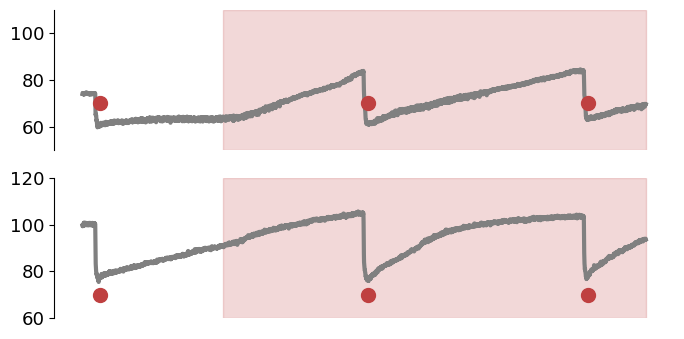

In [182]:
fig, ax = plt.subplots(2, 1, figsize = (8, 4))
stim = 'right'
stim_i = 2
stim_row = stimulus_df[stimulus_df.stim_name == stim].iloc[stim_i]
stim_starttime = stim_row.real_starttime
eye_trace = eye_df[(eye_df.real_time >= stim_starttime) & (eye_df.real_time <= stim_starttime + pd.Timedelta(seconds=40))]
filtered_df = saccade_df[
    saccade_df['cont_tuples_eyeindex'].apply(
        lambda x: x[0] >= eye_trace.index[0] and x[1] <=  eye_trace.index[-1])]
ax[0].plot(eye_trace.th_e0, c = 'grey', linewidth = 3)
ax[1].plot(eye_trace.th_e1, c = 'grey', linewidth = 3)
ax[0].set_ylim([50, 110])
ax[1].set_ylim([60, 120])
for axes in ax:
    axes.spines[['top', 'right', 'bottom']].set_visible(False)
    axes.axvspan(eye_trace.index[0] + fps*10, eye_trace.index[0] + fps*40, color = utils.stim_colors[stim], alpha = 0.2)
    axes.set_xticks([])
    axes.set_xticklabels([])
    axes.scatter([i[0] for i in filtered_df['cont_tuples_eyeindex']], [70] * len(filtered_df), zorder = 2, s = 100, color = utils.stim_colors[stim] )
plt.savefig(examplefish1 + 'eye_example.svg')
plt.show()
plt.close()

In [157]:
saccade_df

,Unnamed: 0,cont_tuples_eyeindex,cont_tuples_realtime_s,e0_change,e1_change,eye_stimuli,eye_realstimuli,eye_fromstart_s,e_conv_change,e_conj_change
0,0,"(np.int64(86), np.int64(136))","(np.float64(-0.6851659999999999), np.float64(-...",-1.469923,0.962149,NaN,NaN,NaN,2.432072,-0.507775
1,1,"(np.int64(794), np.int64(864))","(np.float64(7.288505), np.float64(8.065426))",-5.567973,2.329311,right,stationary,7.288505,7.897284,-3.238662
2,2,"(np.int64(1907), np.int64(1992))","(np.float64(19.648442), np.float64(20.591918))",-14.031013,-9.940612,right,right,19.648442,4.090402,-23.971625
3,3,"(np.int64(2568), np.int64(2652))","(np.float64(27.03269), np.float64(27.966194))",-12.461851,-10.212102,right,right,27.032690,2.249750,-22.673953
4,4,"(np.int64(3580), np.int64(3664))","(np.float64(38.270631), np.float64(39.203135))",-12.724972,-11.058865,right,right,38.270631,1.666107,-23.783837
...,...,...,...,...,...,...,...,...,...,...
110,110,"(np.int64(104131), np.int64(104208))","(np.float64(1178.009431), np.float64(1178.8651...",-8.585731,-2.674128,dot_l,dot_l,16.519808,5.911603,-11.259860
111,111,"(np.int64(108442), np.int64(108523))","(np.float64(1225.881378), np.float64(1226.7809...",-4.152007,-4.658541,pause,stationary,24.323936,-0.506533,-8.810548
112,112,"(np.int64(114816), np.int64(114941))","(np.float64(1296.662045), np.float64(1298.0493...",9.941162,-4.870130,pause,stationary,95.104603,-14.811292,5.071032
113,113,"(np.int64(127247), np.int64(127382))","(np.float64(1434.711774), np.float64(1436.2107...",4.325956,-5.996992,pause,stationary,233.154332,-10.322948,-1.671036
